# Video-Frames mit GPS-Track verknüpfen

Dieses Notebook ordnet jedem extrahierten Video-Frame (`dataset/frames/<video>/original/frame_NNNNN.jpg`)
eine GPS-Position aus dem Strava-Track (`dataset/gpx_data/*.gpx`) zu – über die **Zeitstempel**.

## Idee

- Die Frames werden mit **1 Bild/Sekunde** extrahiert → Frame-Index `N` = `N` Sekunden nach Video-Start.
- Der GPX-Track enthält pro Sekunde einen Punkt mit UTC-Zeit.
- Kennt man die **absolute Startzeit des Videos** (UTC), gilt: `t(Frame N) = t_start + N / fps`.
  Anschließend wird der zeitlich nächstgelegene GPX-Punkt gesucht.

## Achtung: Zeitstempel-Problem

Die `creation_time` in den DJI-Metadaten ist hier **unbrauchbar** (Drohnen-Uhr stand auf 2016),
während der GPX-Track von 2026 stammt. Deshalb wird die Startzeit über einen **manuellen Sync-Punkt**
bestimmt (siehe Abschnitt *Video-Startzeit festlegen*).


## 1. Imports & Projektpfad


In [5]:
from __future__ import annotations

import json
import math
import shutil
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    """Sucht nach oben den Ordner, der ein 'dataset/'-Verzeichnis enthält."""
    for p in [start, *start.parents]:
        if (p / "dataset").is_dir():
            return p
    raise FileNotFoundError("Projekt-Root mit 'dataset/' nicht gefunden.")


PROJECT_ROOT = find_project_root(Path.cwd())
print(f"Projekt-Root: {PROJECT_ROOT}")


Projekt-Root: c:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score


## 2. Konfiguration

Hier legst du fest, welches Video/GPX verarbeitet wird und mit welcher Bildrate die Frames
extrahiert wurden (muss zu `FRAMES_PER_SECOND` aus dem Pre-Processing passen).


In [6]:
VIDEO_NAME = "DJI_0376"          # Ordnername unter dataset/frames/ und Dateiname unter dataset/raw/
GPX_FILE = "Radfahrt_am_Nachmittag.gpx"
FRAMES_PER_SECOND = 1            # muss zur Frame-Extraktion passen
MATCH_TOLERANCE_S = 2.0         # max. Zeitabstand Frame <-> GPS-Punkt (Sekunden)

VIDEO_PATH = PROJECT_ROOT / "dataset" / "raw" / f"{VIDEO_NAME}.MP4"
FRAMES_DIR = PROJECT_ROOT / "dataset" / "frames" / VIDEO_NAME / "original"
GPX_PATH = PROJECT_ROOT / "dataset" / "gpx_data" / GPX_FILE
OUTPUT_CSV = PROJECT_ROOT / "dataset" / "frames" / VIDEO_NAME / "frame_gps_mapping.csv"

for label, p in {"Video": VIDEO_PATH, "Frames": FRAMES_DIR, "GPX": GPX_PATH}.items():
    status = "✅" if p.exists() else "❌ fehlt"
    print(f"{status}  {label:7s}: {p}")


✅  Video  : c:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score\dataset\raw\DJI_0376.MP4
✅  Frames : c:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score\dataset\frames\DJI_0376\original
✅  GPX    : c:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score\dataset\gpx_data\Radfahrt_am_Nachmittag.gpx


## 3. GPX-Track einlesen

Der Track wird in einen `DataFrame` mit Zeit, Position und Höhe geladen. Zusätzlich werden
kumulierte Distanz (Haversine) und Momentangeschwindigkeit berechnet – nützlich für den
späteren Bikeability-Score.


In [7]:
import xml.etree.ElementTree as ET

GPX_NS = {"gpx": "http://www.topografix.com/GPX/1/1"}


def haversine_m(lat1, lon1, lat2, lon2):
    """Distanz in Metern zwischen zwei Lat/Lon-Punkten."""
    r = 6_371_000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlmb / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))


def load_gpx(path: Path) -> pd.DataFrame:
    tree = ET.parse(path)
    rows = []
    for trkpt in tree.findall(".//gpx:trkpt", GPX_NS):
        t = trkpt.find("gpx:time", GPX_NS)
        ele = trkpt.find("gpx:ele", GPX_NS)
        rows.append({
            "time": datetime.fromisoformat(t.text.replace("Z", "+00:00")),
            "lat": float(trkpt.get("lat")),
            "lon": float(trkpt.get("lon")),
            "ele": float(ele.text) if ele is not None else np.nan,
        })
    df = pd.DataFrame(rows).sort_values("time").reset_index(drop=True)

    # Distanz & Geschwindigkeit
    dist = [0.0]
    for i in range(1, len(df)):
        dist.append(haversine_m(df.lat[i - 1], df.lon[i - 1], df.lat[i], df.lon[i]))
    df["step_m"] = dist
    df["dist_m"] = df["step_m"].cumsum()
    dt = df["time"].diff().dt.total_seconds().replace(0, np.nan)
    df["speed_kmh"] = (df["step_m"] / dt) * 3.6
    df["speed_kmh"] = df["speed_kmh"].fillna(0.0)
    return df


gpx = load_gpx(GPX_PATH)
print(f"GPX-Punkte: {len(gpx)}")
print(f"Zeitraum:   {gpx['time'].iloc[0]}  →  {gpx['time'].iloc[-1]}")
print(f"Strecke:    {gpx['dist_m'].iloc[-1] / 1000:.2f} km")
gpx.head()


GPX-Punkte: 8840
Zeitraum:   2026-06-19 14:25:45+00:00  →  2026-06-19 17:23:44+00:00
Strecke:    60.18 km


,time,lat,lon,ele,step_m,dist_m,speed_kmh
0,2026-06-19 14:25:45+00:00,49.136403,9.210773,160.0,0.000000,0.000000,0.000000
1,2026-06-19 14:25:46+00:00,49.136349,9.210865,159.9,8.991728,8.991728,32.370221
2,2026-06-19 14:25:47+00:00,49.136295,9.210957,159.9,8.991734,17.983462,32.370241
3,2026-06-19 14:25:48+00:00,49.136232,9.210854,159.9,10.257863,28.241325,36.928306
4,2026-06-19 14:25:49+00:00,49.136180,9.210796,159.8,7.158047,35.399372,25.768969


## 4. Video-Metadaten lesen (ffprobe)

Es wird versucht, die `creation_time` aus dem Video zu lesen. Diese wird gegen den GPX-Zeitraum
geprüft – liegt sie außerhalb, ist die Drohnen-Uhr nicht gestellt und der Wert wird verworfen.


In [8]:
def find_ffprobe() -> str | None:
    """ffprobe im PATH oder in den WinGet-Paketen suchen."""
    exe = shutil.which("ffprobe")
    if exe:
        return exe
    winget = Path.home() / "AppData/Local/Microsoft/WinGet/Packages"
    if winget.exists():
        hits = list(winget.glob("Gyan.FFmpeg*/**/bin/ffprobe.exe"))
        if hits:
            return str(hits[0])
    return None


def probe_video(video_path: Path):
    """Gibt (creation_time|None, duration_s|None) zurück."""
    ffprobe = find_ffprobe()
    if not ffprobe:
        print("⚠ ffprobe nicht gefunden – Metadaten werden übersprungen.")
        return None, None
    out = subprocess.run(
        [ffprobe, "-v", "quiet", "-print_format", "json",
         "-show_entries", "format_tags=creation_time:format=duration",
         "-i", str(video_path)],
        capture_output=True, text=True,
    )
    data = json.loads(out.stdout or "{}").get("format", {})
    ct = data.get("tags", {}).get("creation_time")
    dur = float(data["duration"]) if "duration" in data else None
    ct_dt = datetime.fromisoformat(ct.replace("Z", "+00:00")) if ct else None
    return ct_dt, dur


meta_creation, video_duration = probe_video(VIDEO_PATH)
gpx_start, gpx_end = gpx["time"].iloc[0], gpx["time"].iloc[-1]

meta_plausible = (
    meta_creation is not None and gpx_start <= meta_creation <= gpx_end
)

print(f"creation_time (Metadaten): {meta_creation}")
print(f"Video-Dauer:               {video_duration:.1f} s" if video_duration else "Video-Dauer: unbekannt")
print(f"GPX-Zeitraum:              {gpx_start} → {gpx_end}")
print(f"→ Metadaten-Zeit plausibel? {'JA' if meta_plausible else 'NEIN (manueller Sync nötig)'}")


creation_time (Metadaten): 2016-02-11 00:36:31+00:00
Video-Dauer:               408.5 s
GPX-Zeitraum:              2026-06-19 14:25:45+00:00 → 2026-06-19 17:23:44+00:00
→ Metadaten-Zeit plausibel? NEIN (manueller Sync nötig)


## 5. Video-Startzeit festlegen (Synchronisation)

Da die Metadaten-Zeit hier unbrauchbar ist, wird die Startzeit über ein **Referenz-Paar**
bestimmt: ein bekannter Frame-Index und die zugehörige echte UTC-Zeit.

Möglichkeiten, den Sync-Punkt zu finden:
- **Erinnerte Startzeit:** Du weißt, wann du die Aufnahme gestartet hast → Wall-Clock in UTC umrechnen
  (Sommerzeit in DE = UTC+2, also z. B. lokal 16:25 → `14:25Z`) und `SYNC_FRAME_INDEX = 0` lassen.
- **Markante Stelle:** Suche einen Frame an einer eindeutigen Kreuzung/Landmarke, lies dessen Index ab
  und trage die GPX-Zeit dieses Punktes ein.

Stelle `SYNC_GPX_TIME` ggf. um, bis die Validierung weiter unten plausibel aussieht.


In [9]:
# --- Sync-Konfiguration ---------------------------------------------------
# Referenz-Frame und die zugehörige echte UTC-Zeit dieses Frames.
SYNC_FRAME_INDEX = 0
# Setze hier die UTC-Zeit, die zu SYNC_FRAME_INDEX gehört. None => GPX-Start verwenden
# (Annahme: Aufnahme begann mit dem Track). Format: "2026-06-19T14:25:45Z"
SYNC_GPX_TIME = None
# -------------------------------------------------------------------------

if SYNC_GPX_TIME is not None:
    sync_time = datetime.fromisoformat(SYNC_GPX_TIME.replace("Z", "+00:00"))
elif meta_plausible:
    sync_time = meta_creation
    SYNC_FRAME_INDEX = 0
    print("ℹ Verwende plausible Metadaten-Zeit als Sync.")
else:
    sync_time = gpx_start
    SYNC_FRAME_INDEX = 0
    print("ℹ Kein Sync gesetzt → Annahme: Video-Start = GPX-Start.")

# Startzeit des Videos (Frame 0) zurückrechnen
VIDEO_START_UTC = sync_time - pd.Timedelta(seconds=SYNC_FRAME_INDEX / FRAMES_PER_SECOND)
print(f"Video-Start (Frame 0, UTC): {VIDEO_START_UTC}")


ℹ Kein Sync gesetzt → Annahme: Video-Start = GPX-Start.
Video-Start (Frame 0, UTC): 2026-06-19 14:25:45+00:00


## 6. Frames mit GPS verknüpfen

Jeder Frame bekommt seine Zeit (`Start + Index / fps`) und wird per Nearest-Match dem
zeitlich nächsten GPX-Punkt zugeordnet. Ergebnis wird als CSV gespeichert.


In [10]:
frame_paths = sorted(FRAMES_DIR.glob("frame_*.jpg"))
if not frame_paths:
    raise FileNotFoundError(f"Keine Frames in {FRAMES_DIR}")

frames = pd.DataFrame({
    "frame": [p.name for p in frame_paths],
    "frame_index": [int(p.stem.split("_")[1]) for p in frame_paths],
})
frames["time"] = VIDEO_START_UTC + pd.to_timedelta(
    frames["frame_index"] / FRAMES_PER_SECOND, unit="s"
)

# GPX-Zeit als eigene Spalte erhalten, damit sie nach dem Merge sichtbar bleibt
gpx_match = gpx.copy()
gpx_match["gpx_time"] = gpx_match["time"]

mapping = pd.merge_asof(
    frames.sort_values("time"),
    gpx_match.sort_values("time"),
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta(seconds=MATCH_TOLERANCE_S),
)

mapping["dt_s"] = (mapping["gpx_time"] - mapping["time"]).dt.total_seconds().abs()
matched = mapping["lat"].notna().sum()

print(f"Frames gesamt:        {len(mapping)}")
print(f"Zugeordnet (≤{MATCH_TOLERANCE_S}s): {matched}")
print(f"Ohne Match:           {len(mapping) - matched}")
print(f"Max. Zeitabstand:     {mapping['dt_s'].max():.2f} s")

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
mapping.to_csv(OUTPUT_CSV, index=False)
print(f"\n💾 gespeichert: {OUTPUT_CSV}")
mapping[["frame", "frame_index", "time", "lat", "lon", "ele", "speed_kmh", "dt_s"]].head()


Frames gesamt:        409
Zugeordnet (≤2.0s): 409
Ohne Match:           0
Max. Zeitabstand:     0.00 s

💾 gespeichert: c:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score\dataset\frames\DJI_0376\frame_gps_mapping.csv


,frame,frame_index,time,lat,lon,ele,speed_kmh,dt_s
0,frame_00000.jpg,0,2026-06-19 14:25:45+00:00,49.136403,9.210773,160.0,0.000000,0.0
1,frame_00001.jpg,1,2026-06-19 14:25:46+00:00,49.136349,9.210865,159.9,32.370221,0.0
2,frame_00002.jpg,2,2026-06-19 14:25:47+00:00,49.136295,9.210957,159.9,32.370241,0.0
3,frame_00003.jpg,3,2026-06-19 14:25:48+00:00,49.136232,9.210854,159.9,36.928306,0.0
4,frame_00004.jpg,4,2026-06-19 14:25:49+00:00,49.136180,9.210796,159.8,25.768969,0.0


## 7. Visualisierung & Validierung

Der komplette Track (grau) mit dem Video-Abschnitt (farbig nach Geschwindigkeit) zeigt sofort,
ob die Synchronisation plausibel ist: Der farbige Abschnitt sollte zusammenhängend auf der
Route liegen. Sieht er falsch aus, passe `SYNC_GPX_TIME` an.


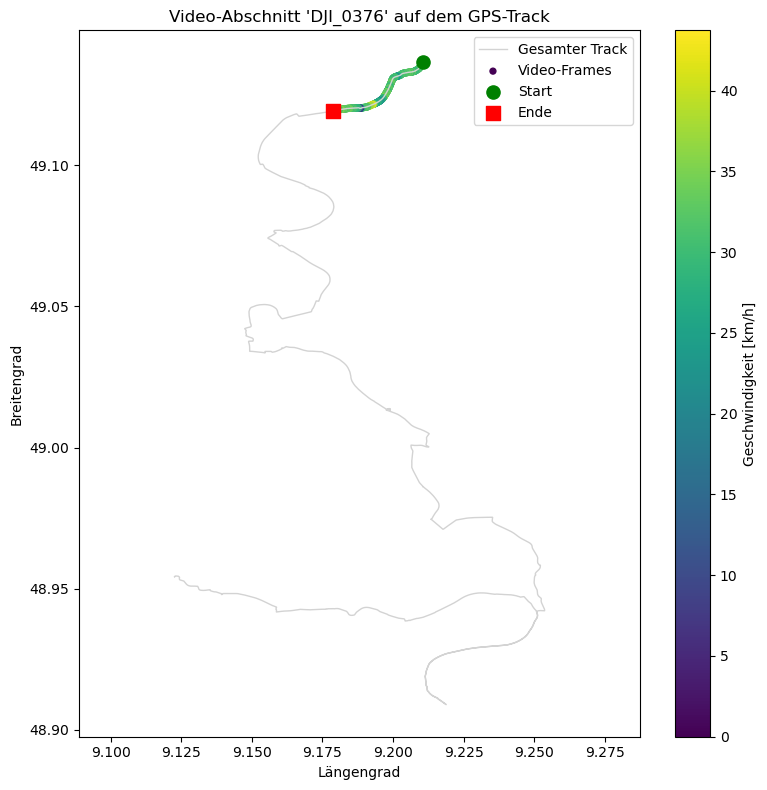

In [11]:
seg = mapping.dropna(subset=["lat", "lon"])

fig, ax = plt.subplots(figsize=(8, 8))
# Gesamter Track als Hintergrund
ax.plot(gpx["lon"], gpx["lat"], color="lightgray", linewidth=1, label="Gesamter Track")
# Video-Abschnitt nach Geschwindigkeit einfärben
sc = ax.scatter(seg["lon"], seg["lat"], c=seg["speed_kmh"], cmap="viridis", s=18, label="Video-Frames")
ax.scatter(seg["lon"].iloc[0], seg["lat"].iloc[0], color="green", s=90, marker="o", label="Start", zorder=5)
ax.scatter(seg["lon"].iloc[-1], seg["lat"].iloc[-1], color="red", s=90, marker="s", label="Ende", zorder=5)

ax.set_xlabel("Längengrad")
ax.set_ylabel("Breitengrad")
ax.set_title(f"Video-Abschnitt '{VIDEO_NAME}' auf dem GPS-Track")
ax.set_aspect("equal", adjustable="datalim")
fig.colorbar(sc, ax=ax, label="Geschwindigkeit [km/h]")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


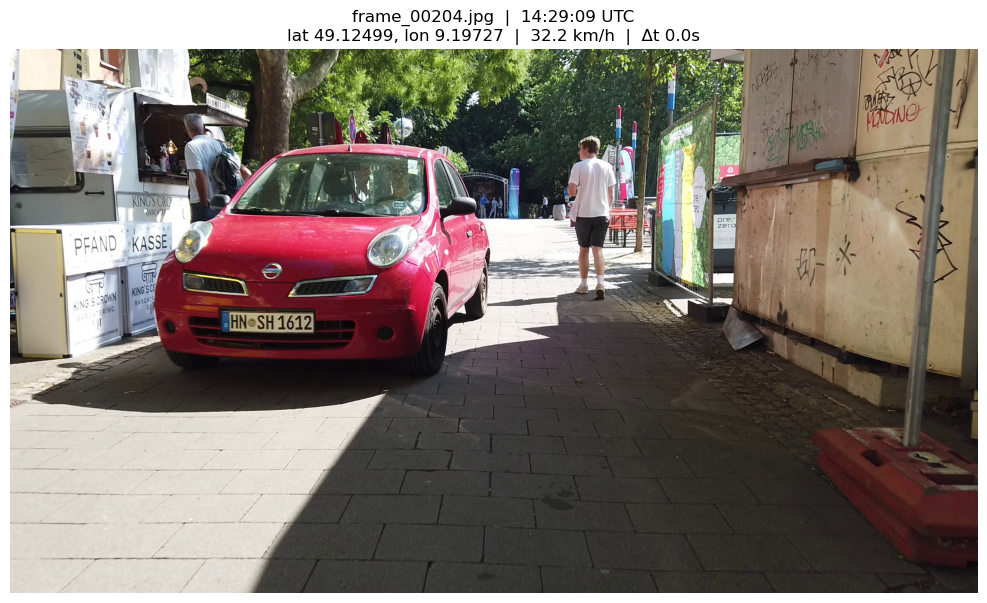

In [12]:
import matplotlib.image as mpimg

# Beispiel-Frame mit zugeordneter Position anzeigen
sample = seg.iloc[len(seg) // 2]
img = mpimg.imread(FRAMES_DIR / sample["frame"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img)
ax.axis("off")
ax.set_title(
    f"{sample['frame']}  |  {sample['time']:%H:%M:%S} UTC\n"
    f"lat {sample['lat']:.5f}, lon {sample['lon']:.5f}  |  "
    f"{sample['speed_kmh']:.1f} km/h  |  Δt {sample['dt_s']:.1f}s"
)
plt.tight_layout()
plt.show()
